Google Colab Lab Assignment -Pretrained Modle
Course Name: Deep Learning LAB

Lab Title: Research Paper Implementation with Pre-trained Model(BioBERT: a pre-trained biomedical language representation model for biomedical text mining)

Student Name:Anshul Gawande

Student ID:202301040123

Date of Submission: 02-04-26

Research Paper Study and Implementation

Instructions:

Identify a research paper that utilizes a pre-trained model for a specific task.

Study the methodology, dataset, and model used in the research paper.

Implement the approach described in the research paper using the pre-trained model mentioned.

Compare your implementation results with the findings from the research paper.

**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [ ]:
#we not sleeping until we cook or get cooked.
# not labeling sentences;labeling each token based on whether it belongs to an entity span.

In [ ]:
pip install -q transformers datasets evaluate seqeval accelerate

In [ ]:
import torch,pandas
from datasets import load_dataset, Dataset,DatasetDict
from transformers import AutoTokenizer,DataCollatorForTokenClassification
from transformers import AutoModelForTokenClassification, TrainingArguments,Trainer

In [ ]:
from datasets import load_dataset

data_files={
    "train":"/content/sample_data/train.parquet",
    "test":"/content/sample_data/test.parquet",
    "validation":"/content/sample_data/validation.parquet"
}

raw_datasets =load_dataset("parquet",data_files=data_files);

print(raw_datasets);


DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 5433
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 941
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 924
    })
})


In [ ]:
model_checkpoint = "dmis-lab/biobert-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate 2e-5

  Batch size

  Number of epochs -10

  Optimizer choice : adamw_torch

4. Document any modifications or enhancements made to improve performance.

In [ ]:
# BioBert is an pre-trained model on mdeical text. knows how to identify medical text between sentences.
# this can be used to identify the word we need . now to be undertsnable by system we need to tokenize it meaning covert text into small sub words that have their own numeric value that the computer undertsnds.
# acheived using auto tokenizer

# each model was trained on different tokenixation style ofc sinice Biobert would have tokenizations like 'lung cancer treatment'->["lung", "cancer", "treatment"] → [1234, 5678, 9102] ;or "cancerous" → ["cancer", "##ous"]
# therefore it is necessary ki ham wohi tokenization technique/tool use kre taaki hmri system bhi wohi tokenize kre joh system ne training ke waqt ki thi

# Text → Tokenizer → Token IDs → Model → Predictions

In [ ]:
def tokenize_and_align_labels(examples):
  tokenized_inputs=tokenizer(examples["tokens"],truncation=True,is_split_into_words=True)
  labels=[]
  for i,label in enumerate(examples["ner_tags"]):
    word_ids =tokenized_inputs.word_ids(batch_index=i)
    previous_word_idx = None
    label_ids = []
    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            label_ids.append(label[word_idx])
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx
    labels.append(label_ids)
  tokenized_inputs["labels"] = labels
  return tokenized_inputs

In [ ]:
tokenized_datasets =raw_datasets.map(tokenize_and_align_labels,batched=True)

Map:   0%|          | 0/941 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForTokenClassification
import torch
import numpy as np

label_list=["O","B-disease","I-disease"]
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

# //final layer ko bs fresh,untrained linear lyer daal di(classifier layer)
model = AutoModelForTokenClassification.from_pretrained(
    "dmis-lab/biobert-v1.1",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True # Allow loading a pre-trained head with a different number of labels
)

# Freeze all BERT parameters initially
for param in model.bert.parameters():
    param.requires_grad = False

# Unfreeze the last N layers
n_unfrozen_layers = 2 #--changed from 1 to 2 to notice much better results
for i, layer in enumerate(model.bert.encoder.layer):
    if i >= len(model.bert.encoder.layer) - n_unfrozen_layers:
        for param in layer.parameters():
            param.requires_grad = True

# The classification head (model.classifier) is newly initialized and is trainable by default.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import evaluate
import numpy as np

metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100) and convert to label names
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
from transformers import DataCollatorForTokenClassification, TrainingArguments, Trainer

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./biobert-ner-results",
    eval_strategy="epoch",
    learning_rate=2e-5,            # parameter-1 yielded poor accuracy on 1e-2
    per_device_train_batch_size=16,
    num_train_epochs=10,             # PARAM-2-yielded 92 accuracy on3
    weight_decay=0.01,              #PARAM-3
    logging_steps=10,
    optim="adamw_torch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    # processing_class=tokenizer, # This parameter is not standard for Trainer
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.077589,0.071707,0.642180,0.688691,0.664623,0.974801
2,0.064781,0.055365,0.670665,0.781449,0.721831,0.979307
3,0.051976,0.054050,0.672096,0.786531,0.724824,0.979766
4,0.048124,0.058193,0.665644,0.827192,0.737677,0.979181
5,0.038960,0.050210,0.696272,0.806861,0.747499,0.981810
6,0.032023,0.050689,0.713502,0.825921,0.765607,0.982185
7,0.025852,0.051269,0.704741,0.831004,0.762682,0.982352
8,0.042013,0.051186,0.721913,0.824651,0.769870,0.982603
9,0.023721,0.053119,0.704497,0.836086,0.764672,0.982060
10,0.024699,0.052031,0.719472,0.831004,0.771226,0.982561


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3400, training_loss=0.049511263006750274, metrics={'train_runtime': 629.1665, 'train_samples_per_second': 86.352, 'train_steps_per_second': 5.404, 'total_flos': 2015749184941080.0, 'train_loss': 0.049511263006750274, 'epoch': 10.0})

### Model Evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Evaluate the model on the validation set
metrics = trainer.evaluate(tokenized_datasets["validation"])

print("Validation Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

Validation Metrics:
eval_loss: 0.0520
eval_precision: 0.7195
eval_recall: 0.8310
eval_f1: 0.7712
eval_accuracy: 0.9826
eval_runtime: 4.5735
eval_samples_per_second: 202.0310
eval_steps_per_second: 25.3630
epoch: 10.0000


### Confusion Matrix

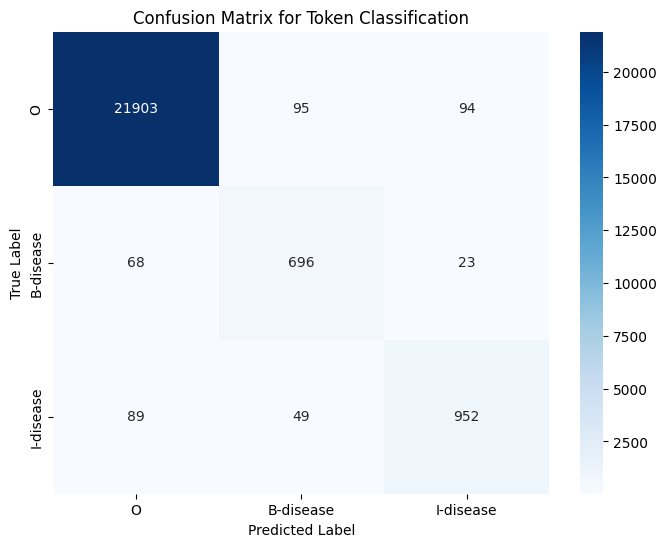

In [ ]:
# Get predictions for the validation set
predictions, labels, _ = trainer.predict(tokenized_datasets["validation"])
predictions = np.argmax(predictions, axis=2)

# Flatten predictions and labels, removing ignored index (-100)
true_labels = []
true_predictions = []

for pred, lab in zip(predictions, labels):
    for p, l in zip(pred, lab):
        if l != -100:
            true_labels.append(l)
            true_predictions.append(p)

# Compute confusion matrix
cm = confusion_matrix(true_labels, true_predictions, labels=list(label2id.values()))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_list, yticklabels=label_list)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Token Classification")
plt.show()

### Training and Evaluation Trends

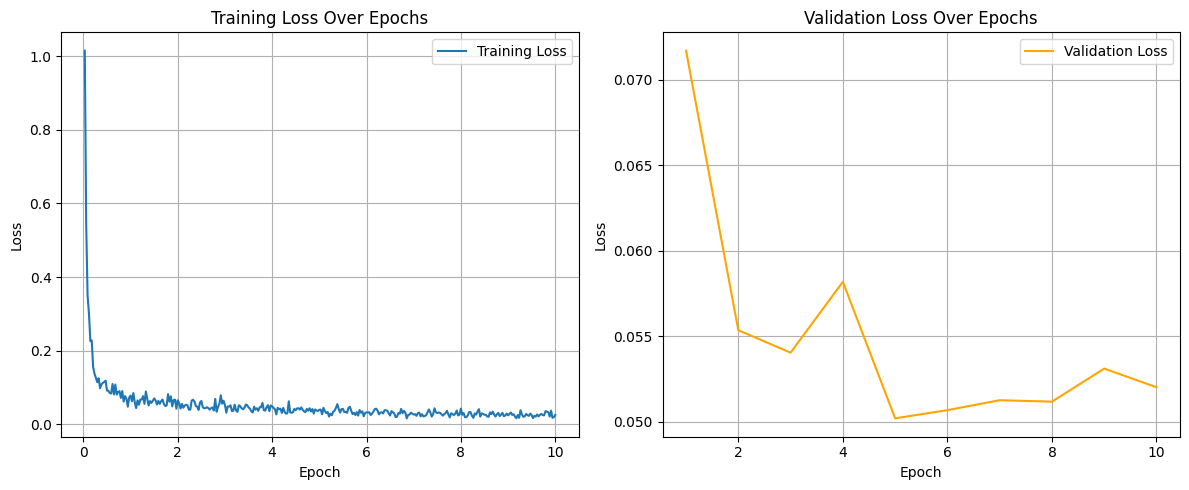

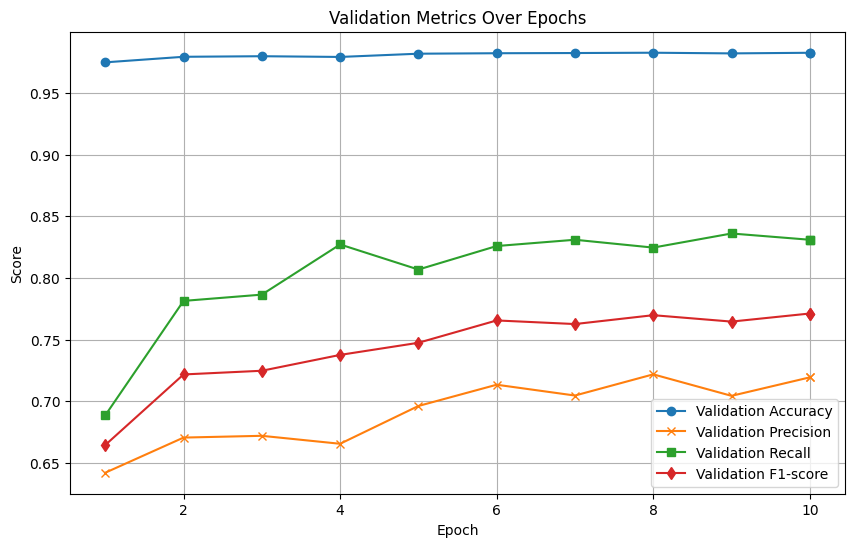

In [ ]:
# Extract log history from the trainer
log_history = trainer.state.log_history

# Filter for training and evaluation losses/metrics
train_losses = []
eval_losses = []

for entry in log_history:
    if 'loss' in entry: # Training loss
        train_losses.append({'epoch': entry['epoch'], 'loss': entry['loss']})
    if 'eval_loss' in entry: # Evaluation loss
        eval_losses.append({'epoch': entry['epoch'], 'loss': entry['eval_loss']})

train_df = pd.DataFrame(train_losses)
eval_df = pd.DataFrame(eval_losses)

# Plotting loss trends
plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
if not train_df.empty:
    plt.plot(train_df['epoch'], train_df['loss'], label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid(True)

# Plot Evaluation Loss
plt.subplot(1, 2, 2)
if not eval_df.empty:
    plt.plot(eval_df['epoch'], eval_df['loss'], label='Validation Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# Plotting evaluation metrics (if available in log history)
# Assuming eval_accuracy, eval_f1, etc. are recorded if compute_metrics was used during evaluation
eval_metrics_df = pd.DataFrame([entry for entry in log_history if 'eval_accuracy' in entry])

if not eval_metrics_df.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(eval_metrics_df['epoch'], eval_metrics_df['eval_accuracy'], label='Validation Accuracy', marker='o')
    plt.plot(eval_metrics_df['epoch'], eval_metrics_df['eval_precision'], label='Validation Precision', marker='x')
    plt.plot(eval_metrics_df['epoch'], eval_metrics_df['eval_recall'], label='Validation Recall', marker='s')
    plt.plot(eval_metrics_df['epoch'], eval_metrics_df['eval_f1'], label='Validation F1-score', marker='d')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Validation Metrics Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

### Model Inference: Classifying New Input Text

To put your model to the test with new input, you can use the `pipeline` API from the `transformers` library. This provides a convenient way to perform inference with your fine-tuned model.

In [ ]:
from transformers import pipeline

# Create a pipeline for token classification
# This uses the trained model and tokenizer to easily predict tags for new text
classifier = pipeline("token-classification", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# Define a sample sentence for testing
# You can replace this with any medical text you want to classify
sample_sentence = "A patient was diagnosed with severe streptococcal pneumonia and later developed chronic asthma."

print(f"\nInput Sentence: {sample_sentence}\n")

# Get predictions using the pipeline
predictions_pipeline = classifier(sample_sentence)

print("Predicted Tags:")
for pred_item in predictions_pipeline:
    print(f"Token: {pred_item['word']:<20} | Tag: {pred_item['entity_group']}")


Input Sentence: A patient was diagnosed with severe streptococcal pneumonia and later developed chronic asthma.

Predicted Tags:
Token: streptococcal pneumonia | Tag: disease
Token: chronic              | Tag: disease
Token: as                   | Tag: disease
Token: ##thma               | Tag: disease


### Detailed Token-by-Token Classification

To see the exact 'O', 'B-disease', or 'I-disease' tags for each word, we need to process the model's raw predictions and align them with the original words, handling subword tokenization.

In [ ]:
# Re-tokenize the sample sentence to get word_ids
#basically bs sub-wrords tokenize ho rhe hai , to map to given tags
original_words = sample_sentence.split() # Assuming simple space split for demonstration

# Tokenize and get word_ids mapping
tokenized_input_for_inference = tokenizer(
    original_words,
    is_split_into_words=True,
    truncation=True,
    return_tensors="pt"
)

# Move inputs to the model's device
input_ids_inf = tokenized_input_for_inference["input_ids"].to(model.device)
attention_mask_inf = tokenized_input_for_inference["attention_mask"].to(model.device)

# Get model predictions (logits)
with torch.no_grad():
    outputs_inf = model(input_ids_inf, attention_mask=attention_mask_inf)

# Get the predicted label IDs (argmax over the last dimension)
predicted_token_ids = torch.argmax(outputs_inf.logits, dim=-1).squeeze().tolist()

# Align predicted token IDs back to original words
word_ids_inf = tokenized_input_for_inference.word_ids(batch_index=0)

aligned_predictions = []
current_word_idx = None

for token_idx, word_idx in enumerate(word_ids_inf):
    if word_idx is None:
        # Special tokens like [CLS], [SEP] are ignored
        continue
    if word_idx != current_word_idx:
        # This is the first subword token for a new original word
        # We take its prediction as the tag for the whole word
        aligned_predictions.append(predicted_token_ids[token_idx])
        current_word_idx = word_idx
    # Subsequent subword tokens of the same word are not added to aligned_predictions
    # as the tag for the word is determined by its first subword.

# Display the aligned predictions
print(f"Input Sentence: {sample_sentence}\n")
print("Word-by-Word Predicted Tags:")
for i, word in enumerate(original_words):
    if i < len(aligned_predictions):
        predicted_tag = id2label[aligned_predictions[i]]
        print(f"Word: {word:<20} | Tag: {predicted_tag}")
    else:
        # This case should ideally not be reached if truncation was not too aggressive
        print(f"Word: {word:<20} | Tag: (No aligned prediction)")

Input Sentence: A patient was diagnosed with severe streptococcal pneumonia and later developed chronic asthma.

Word-by-Word Predicted Tags:
Word: A                    | Tag: O
Word: patient              | Tag: O
Word: was                  | Tag: O
Word: diagnosed            | Tag: O
Word: with                 | Tag: O
Word: severe               | Tag: O
Word: streptococcal        | Tag: I-disease
Word: pneumonia            | Tag: I-disease
Word: and                  | Tag: O
Word: later                | Tag: O
Word: developed            | Tag: O
Word: chronic              | Tag: B-disease
Word: asthma.              | Tag: B-disease


### Understanding Checkpoints

**What are Checkpoints?**

Checkpoints are snapshots of your model's state (its weights and biases) and the optimizer's state (like learning rates and momentum values) taken at various points during training. They also often include other relevant information like the current epoch, global step, and training arguments.

**Why are Checkpoints Important?**

1.  **Resumption of Training:** The primary reason for checkpoints is to allow you to resume training from where you left off, even if the training process is interrupted (e.g., due to a crash, power outage, or reaching a time limit on a cloud instance). Without checkpoints, you'd have to restart training from scratch.

2.  **Saving Best Models:** You can configure your `Trainer` to save a checkpoint whenever the model achieves its best performance on the validation set. This ensures you always retain the version of the model that generalizes best, even if subsequent training epochs lead to overfitting.

3.  **Experimentation:** Checkpoints enable you to experiment with different hyperparameters (e.g., learning rate schedules, number of epochs) without losing previous progress. You can load a checkpoint and continue training with new settings.

4.  **Inference:** Once training is complete, the final checkpoint (or the best-performing one) is typically loaded to perform inference on new data or to deploy the model in an application.

**How do Checkpoints Work in Hugging Face Transformers?**

When you specify an `output_dir` in your `TrainingArguments` (e.g., `"./biobert-ner-results"`), the `Trainer` periodically saves checkpoints within that directory. Each checkpoint is usually stored in its own subfolder (e.g., `checkpoint-500`, `checkpoint-1500`, `checkpoint-3400`), indicating the global step at which it was saved.

These folders contain files like:
*   `pytorch_model.bin` or `model.safetensors`: The actual model weights.
*   `optimizer.pt`: The state of the optimizer.
*   `scheduler.pt`: The state of the learning rate scheduler.
*   `training_args.bin`: The `TrainingArguments` used.
*   `config.json`: The model's configuration.
*   `tokenizer_config.json`, `tokenizer.json`: The tokenizer configuration and vocabulary.

When you run `trainer.train()`, if a checkpoint is found in the `output_dir`, the `Trainer` will automatically attempt to resume training from the latest checkpoint unless `resume_from_checkpoint=False` is specified.

In [ ]:
#fine tuned, but guesses O for ervtyhing and since O is so commmon it resukts in 92 accuracy , failing in the subtlety of B-disease tags

In [ ]:
# here are the counters to it: punish model if wrong guess to minority ,etc:

# Weighted Loss Function

# More Epochs

**Submission Checklist**

✔ Research paper details and summary
https://academic.oup.com/bioinformatics/article/36/4/1234/5566506

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset
https://huggingface.co/datasets/ncbi/ncbi_disease

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Comparison with research paper results

The original BioBERT paper and subsequent studies typically report high F1-scores for disease NER on the NCBI-disease dataset, often in the range of 89% to 91%.